# Fama-French Three-Factor Model

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **CAPM and Fama–French Models** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on practical implementation details, including data preparation, model development, training procedures, evaluation workflows, and complementary computational experiments.

## Imports and Configuration

This section loads the main Python libraries used throughout the notebook and defines a few global settings for data manipulation, visualization, and statistical modeling.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data acquisition
import yfinance as yf
import pandas_datareader.data as web

# Statistical modeling
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt

# Warning management
import warnings
warnings.filterwarnings("ignore")

# Configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.6f}".format)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## Data Selection

This section defines the asset, benchmark, and time window used in the empirical analysis. The implementation focuses on Apple Inc. as the target asset and uses the Fama–French three-factor data to explain its excess returns.

In [2]:
# Asset and time window
ticker = "AAPL"

start_date = "2020-01-01"
end_date = "2024-12-31"

## Data Acquisition

This section downloads the stock price data and the Fama–French three-factor data required to estimate the model.

In [3]:
# Download adjusted stock prices
stock_data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [4]:
# Download Fama-French three-factor data
ff_factors = web.DataReader(
    "F-F_Research_Data_Factors_daily",
    "famafrench",
    start=start_date,
    end=end_date
)[0]

ff_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2020-01-02,0.860000,-0.880000,-0.340000,0.010000
2020-01-03,-0.670000,0.380000,0.010000,0.010000
2020-01-06,0.360000,-0.070000,-0.550000,0.010000
2020-01-07,-0.190000,-0.010000,-0.260000,0.010000
2020-01-08,0.470000,-0.070000,-0.640000,0.010000


## Data Preparation

This section computes Apple daily returns, aligns them with the Fama–French factors, and defines the dependent and explanatory variables used in the regression model.

In [5]:
# Compute daily stock returns
stock_returns = stock_data["Close"].pct_change().dropna()

# Convert to Series if yfinance returns a DataFrame
if isinstance(stock_returns, pd.DataFrame):
    stock_returns = stock_returns.iloc[:, 0]

# Rename series
stock_returns = stock_returns.rename("AAPL_Return")

stock_returns.head()

Date
2020-01-03   -0.009722
2020-01-06    0.007968
2020-01-07   -0.004703
2020-01-08    0.016086
2020-01-09    0.021241
Name: AAPL_Return, dtype: float64

In [6]:
# Convert Fama-French factors from percentages to decimal returns
ff_factors = ff_factors / 100

ff_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2020-01-02,0.008600,-0.008800,-0.003400,0.000100
2020-01-03,-0.006700,0.003800,0.000100,0.000100
2020-01-06,0.003600,-0.000700,-0.005500,0.000100
2020-01-07,-0.001900,-0.000100,-0.002600,0.000100
2020-01-08,0.004700,-0.000700,-0.006400,0.000100


In [7]:
# Merge stock returns with Fama-French factors
data = pd.concat([stock_returns, ff_factors], axis=1).dropna()

data.head()

,AAPL_Return,Mkt-RF,SMB,HML,RF
Date,,,,,
2020-01-03,-0.009722,-0.006700,0.003800,0.000100,0.000100
2020-01-06,0.007968,0.003600,-0.000700,-0.005500,0.000100
2020-01-07,-0.004703,-0.001900,-0.000100,-0.002600,0.000100
2020-01-08,0.016086,0.004700,-0.000700,-0.006400,0.000100
2020-01-09,0.021241,0.006500,-0.006300,-0.004800,0.000100


In [8]:
# Compute Apple excess returns
data["AAPL_Excess_Return"] = data["AAPL_Return"] - data["RF"]

data.head()

,AAPL_Return,Mkt-RF,SMB,HML,RF,AAPL_Excess_Return
Date,,,,,,
2020-01-03,-0.009722,-0.006700,0.003800,0.000100,0.000100,-0.009822
2020-01-06,0.007968,0.003600,-0.000700,-0.005500,0.000100,0.007868
2020-01-07,-0.004703,-0.001900,-0.000100,-0.002600,0.000100,-0.004803
2020-01-08,0.016086,0.004700,-0.000700,-0.006400,0.000100,0.015986
2020-01-09,0.021241,0.006500,-0.006300,-0.004800,0.000100,0.021141


In [9]:
# Define dependent variable
y = data["AAPL_Excess_Return"]

# Define explanatory variables
X = data[["Mkt-RF", "SMB", "HML"]]

# Add intercept term
X = sm.add_constant(X)

X.head()

,const,Mkt-RF,SMB,HML
Date,,,,
2020-01-03,1.000000,-0.006700,0.003800,0.000100
2020-01-06,1.000000,0.003600,-0.000700,-0.005500
2020-01-07,1.000000,-0.001900,-0.000100,-0.002600
2020-01-08,1.000000,0.004700,-0.000700,-0.006400
2020-01-09,1.000000,0.006500,-0.006300,-0.004800


## Model Estimation

This section estimates the Fama–French three-factor model using ordinary least squares (OLS) regression.

In [10]:
# Fit Fama-French three-factor model
model = sm.OLS(y, X).fit()

# Display regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     AAPL_Excess_Return   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     878.2
Date:                Sun, 24 May 2026   Prob (F-statistic):          2.50e-307
Time:                        18:48:33   Log-Likelihood:                 3845.5
No. Observations:                1256   AIC:                            -7683.
Df Residuals:                    1252   BIC:                            -7662.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.422      0.1

## Model Diagnostics

This section compares observed and fitted excess returns and evaluates the residual behavior of the model.

In [11]:
# Compute fitted values and residuals
data["Fitted_Returns"] = model.fittedvalues

data["Residuals"] = model.resid

data.head()

,AAPL_Return,Mkt-RF,SMB,HML,RF,AAPL_Excess_Return,Fitted_Returns,Residuals
Date,,,,,,,,
2020-01-03,-0.009722,-0.006700,0.003800,0.000100,0.000100,-0.009822,-0.008624,-0.001198
2020-01-06,0.007968,0.003600,-0.000700,-0.005500,0.000100,0.007868,0.006910,0.000958
2020-01-07,-0.004703,-0.001900,-0.000100,-0.002600,0.000100,-0.004803,-0.000757,-0.004046
2020-01-08,0.016086,0.004700,-0.000700,-0.006400,0.000100,0.015986,0.008523,0.007464
2020-01-09,0.021241,0.006500,-0.006300,-0.004800,0.000100,0.021141,0.011868,0.009273


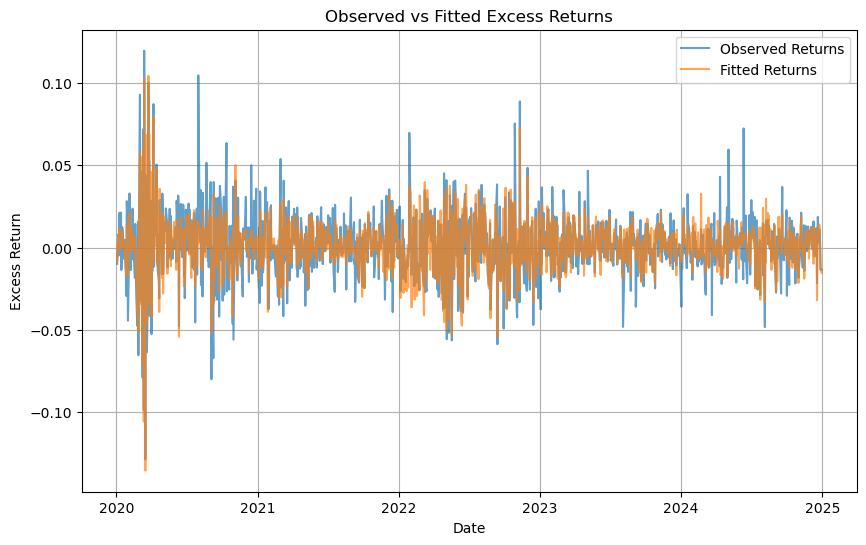

In [12]:
# Plot observed vs fitted excess returns
plt.figure(figsize=(10, 6))

plt.plot(
    data.index,
    data["AAPL_Excess_Return"],
    label="Observed Returns",
    alpha=0.7
)

plt.plot(
    data.index,
    data["Fitted_Returns"],
    label="Fitted Returns",
    alpha=0.7
)

plt.title("Observed vs Fitted Excess Returns")
plt.xlabel("Date")
plt.ylabel("Excess Return")

plt.legend()

plt.show()

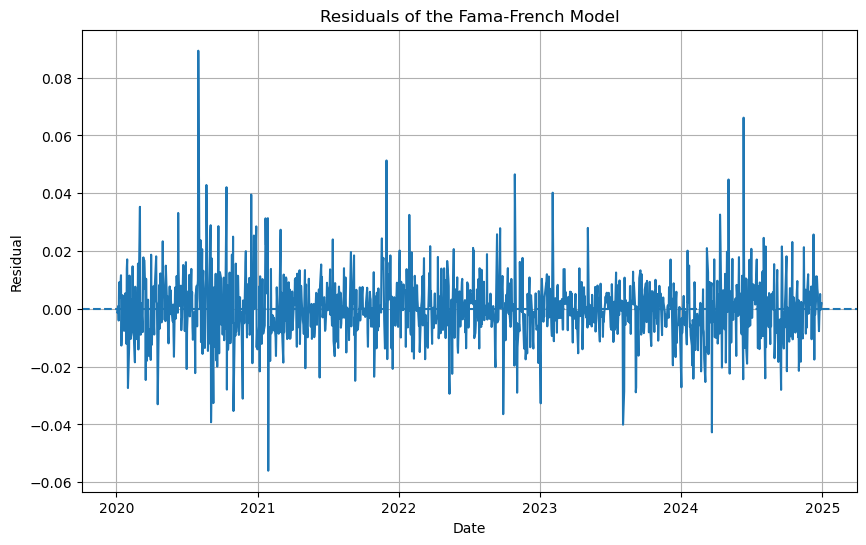

In [13]:
# Plot residuals
plt.figure(figsize=(10, 6))

plt.plot(
    data.index,
    data["Residuals"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals of the Fama-French Model")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

## Final Remarks

The Fama–French three-factor model extends the CAPM framework by incorporating size and value risk factors in addition to market risk. The estimated regression suggests that these additional factors contribute to explaining part of the variability in Apple excess returns over the selected period.